#  Qwen-3B Fine-tuning с QLoRA
## Шаг 2: Fine-tuning + Шаг 3: Evaluation

- *Шаг 2*: Дообучение Qwen-3B через QLoRA (4-bit quantization + LoRA адаптеры)
- *Шаг 3*: Оценку базовой и дообученной модели через BERTScore


---
Установка зависимостей

In [3]:
# Устанавливаем все необходимые библиотеки
# Запускай эту ячейку один раз перед началом работы

!pip install -q \
    transformers \
    peft \
    datasets \
    trl \
    bitsandbytes \
    accelerate \
    bert-score \
    scipy \
    protobuf \

print("Все зависимости установлены")

Все зависимости установлены


---
Запускаю cuda через видеокарту

In [1]:


import torch
import subprocess


# Проверяем доступность CUDA
if not torch.cuda.is_available():
    raise RuntimeError(
        " CUDA не найдена!"
    )

# Выводим информацию о GPU
gpu_count = torch.cuda.device_count()
print(f"CUDA доступна")


for i in range(gpu_count):
    gpu_name = torch.cuda.get_device_name(i)
    gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1024**3  # Конвертируем байты в GB
    print(f"GPU {i}: {gpu_name}")
    print(f"Видеопамять: {gpu_memory:.1f} GB")

print()
print(f"Версия CUDA: {torch.version.cuda}")
print(f"Версия PyTorch: {torch.__version__}")

# Устанавливаем основное устройство
DEVICE = "cuda"
print(f"\nРабочее устройство: {DEVICE}")

CUDA доступна
GPU 0: NVIDIA GeForce RTX 4060 Laptop GPU
Видеопамять: 8.0 GB

Версия CUDA: 13.0
Версия PyTorch: 2.10.0+cu130

Рабочее устройство: cuda


---
## Загрузка и подготовка датасета

In [ ]:
# Загружаю датасет из JSONL файла и преобразую в формат для instruction tuning
# Формат входного файла: {"instruction": "...", "response": "..."}

import json
import random
from datasets import Dataset


DATASET_PATH = "cleaned_dataset.jsonl"  # Путь к датасету
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"  # Модель из Hugging Face
ADAPTER_OUTPUT_DIR = "./adapter"  # Папка для сохранения LoRA адаптера
EVAL_SAMPLES = 20  # Количество примеров для оценки
RANDOM_SEED = 42  # Фиксирую seed для воспроизводимости

random.seed(RANDOM_SEED)

# Читаем JSONL файл построчно
raw_data = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:  # Пропускаем пустые строки
            raw_data.append(json.loads(line))



print(f"Загружено примеров: {len(raw_data)}")
print(f"\nПример первой записи:")
print(f"  Instruction: {raw_data[0]['instruction'][:100]}...")
print(f"  Response: {raw_data[0]['response'][:100]}...")

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загружено примеров: 250

Пример первой записи:
  Instruction: Что это за остров, на котором эта французская компания посадила кофе в Йемене?...
  Response: Французская компания посадила кофе на острове Бурбон рядом с Мадагаскаром....


In [3]:
def format_instruction(example):
    """
    Qwen2.5 использует ChatML формат:
    
    <|im_start|>system
    You are a helpful assistant.<|im_end|>
    <|im_start|>user
    {instruction}<|im_end|>
    <|im_start|>assistant
    {response}<|im_end|>
    """
    instruction = example["instruction"]
    response = example["response"]

    formatted_text = (
        "<|im_start|>system\n"
        "You are a helpful assistant.<|im_end|>\n"
        "<|im_start|>user\n"
        f"{instruction}<|im_end|>\n"
        "<|im_start|>assistant\n"
        f"{response}<|im_end|>"
    )

    return {"text": formatted_text}

In [4]:
# Запусти эту ячейку ПЕРВОЙ перед загрузкой модели
import gc
import torch

# Удаляем всё что могло остаться в памяти
try:
    del model
except: pass
try:
    del tokenizer  
except: pass

gc.collect()
torch.cuda.empty_cache()

print(f"Память очищена")
print(f"RAM свободно: проверь в диспетчере задач")

Память очищена
RAM свободно: проверь в диспетчере задач


---
## Загрузка модели с 4-bit квантизацией (QLoRA)

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Загружаем токенизатор Qwen2.5...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

# У Qwen есть свой pad_token, но проверяем на всякий случай
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"  Токенизатор загружен")
print(f"  Размер словаря: {tokenizer.vocab_size}")

print("\nЗагружаем Qwen2.5-7B в 4-bit...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,   # снижает пик RAM при загрузке
    dtype=torch.bfloat16
)

model = prepare_model_for_kbit_training(model)
print("Модель готова к QLoRA обучению!")

Загружаем токенизатор Qwen2.5...


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--Qwen--Qwen2.5-3B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  Токенизатор загружен
  Размер словаря: 151643

Загружаем Qwen2.5-7B в 4-bit...


Loading weights: 100%|██████████| 434/434 [00:07<00:00, 59.11it/s] 


Модель готова к QLoRA обучению!


In [15]:

dataset = Dataset.from_list(raw_data)
dataset = dataset.map(format_instruction, remove_columns=dataset.column_names)

split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(len(train_dataset), len(eval_dataset))

Map: 100%|██████████| 250/250 [00:00<00:00, 10145.97 examples/s]

225 25


---
## Настройка LoRA адаптеров

In [16]:
# Настраиваем LoRA адаптеры
# 
# LoRA (Low-Rank Adaptation) — добавляет обучаемые матрицы малого ранга
# к замороженным весам основной модели.
# Вместо обучения 7B параметров — обучаем ~10M параметров LoRA.

from peft import LoraConfig, TaskType, get_peft_model

# Конфигурация LoRA
lora_config = LoraConfig(
    # r — ранг матриц LoRA (больше = больше параметров, лучше качество, но медленнее)
    # Для 7B модели r=16 — хороший баланс
    r=16,
    
    # alpha — коэффициент масштабирования LoRA (обычно = r или 2*r)
    lora_alpha=32,
    
    # target_modules — какие слои адаптировать
    # Для Mistral: q_proj, v_proj — минимум; добавляем k_proj, o_proj для лучшего качества
    target_modules=[
        "q_proj",   # Query проекция в self-attention
        "k_proj",   # Key проекция в self-attention
        "v_proj",   # Value проекция в self-attention
        "o_proj",   # Output проекция в self-attention
        "gate_proj", # Gate в MLP (SwiGLU активация)
        "up_proj",   # Up проекция в MLP
        "down_proj", # Down проекция в MLP
    ],
    
    # dropout для регуляризации LoRA слоёв
    lora_dropout=0.05,
    
    # bias — обычно не обучаем
    bias="none",
    
    # Тип задачи — языковое моделирование
    task_type=TaskType.CAUSAL_LM
)

# Применяем LoRA к модели
model = get_peft_model(model, lora_config)

# Выводим статистику параметров
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Статистика параметров модели:")
print(f"  Обучаемых параметров (LoRA): {trainable_params:,}")
print(f"  Всего параметров: {total_params:,}")
print(f"  Доля обучаемых: {100 * trainable_params / total_params:.2f}%")
print()
print("LoRA адаптеры настроены!")
print(f"   Ранг (r): {lora_config.r}")
print(f"   Alpha: {lora_config.lora_alpha}")
print(f"   Целевые модули: {lora_config.target_modules}")

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Статистика параметров модели:
  Обучаемых параметров (LoRA): 29,933,568
  Всего параметров: 1,728,606,208
  Доля обучаемых: 1.73%

LoRA адаптеры настроены!
   Ранг (r): 16
   Alpha: 32
   Целевые модули: {'down_proj', 'o_proj', 'v_proj', 'gate_proj', 'k_proj', 'up_proj', 'q_proj'}


---
## Настройка и запуск обучения (SFTTrainer)

In [17]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./checkpoints",
    num_train_epochs=3,
    
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    weight_decay=0.001,
    
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    
    logging_steps=10,
    logging_dir="./logs",
    
    save_steps=50,
    save_total_limit=2,
    
    eval_strategy="steps",
    eval_steps=50,
    
    fp16=False,
    bf16=True,
    gradient_checkpointing=True,
    
    report_to="none",
    
    max_length=512,              # ← было max_seq_length, теперь max_length
    dataset_text_field="text",
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

print("SFTTrainer настроен!")
print(f"  Эпох: {training_args.num_train_epochs}")
print(f"  Батч: {training_args.per_device_train_batch_size}")
print(f"  Накопление градиентов: {training_args.gradient_accumulation_steps}")
print(f"  Learning rate: {training_args.learning_rate}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
C:\Users\ASUS\AppData\Local\Temp\ipykernel_5380\2477242398.py:3: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(
Tokenizing eval dataset: 100%|██████████| 25/25 [00:00<00:00, 3329.34 examples/s]

SFTTrainer настроен!
  Эпох: 3
  Батч: 1
  Накопление градиентов: 8
  Learning rate: 0.0002


In [18]:


import os
os.makedirs(ADAPTER_OUTPUT_DIR, exist_ok=True)

print("Начинаем обучение...")
print("   Прогресс будет показан ниже")
print()

# Запускаем обучение
train_result = trainer.train()

print("\nОбучение завершено!")
print(f"  Время обучения: {train_result.metrics['train_runtime']:.1f} сек")
print(f"  Финальный loss: {train_result.metrics['train_loss']:.4f}")
print(f"  Шагов выполнено: {train_result.metrics['train_steps_per_second']:.2f} шаг/сек")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Начинаем обучение...
   Прогресс будет показан ниже



Step,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
50,1.227365,1.344569,1.238418,0.707049,30161.000000
87,1.113238,1.339926,1.227267,0.711045,51681.000000



Обучение завершено!
  Время обучения: 429.9 сек
  Финальный loss: 1.4510
  Шагов выполнено: 0.20 шаг/сек


---
## Сохранение LoRA адаптера

In [19]:
# Сохраняем ТОЛЬКО LoRA адаптер (не всю модель!)
# 
# Размер адаптера: ~50-100MB (вместо 14GB для полной модели)
# При загрузке: базовая модель + адаптер = полноценная fine-tuned модель

print(f"Сохраняем LoRA адаптер в '{ADAPTER_OUTPUT_DIR}'...")

# Сохраняем только адаптер (не полную модель)
trainer.model.save_pretrained(ADAPTER_OUTPUT_DIR)

# Сохраняем токенизатор (нужен для загрузки)
tokenizer.save_pretrained(ADAPTER_OUTPUT_DIR)

# Проверяем что сохранилось
import os
saved_files = os.listdir(ADAPTER_OUTPUT_DIR)

print(f"\nАдаптер сохранён!")
print(f"Файлы в '{ADAPTER_OUTPUT_DIR}':")
for f in saved_files:
    size = os.path.getsize(os.path.join(ADAPTER_OUTPUT_DIR, f)) / 1024**2
    print(f"  {f}: {size:.1f} MB")

print(f"\nПримечание: полная модель НЕ сохранялась")
print(f"   Для загрузки используй: PeftModel.from_pretrained(base_model, '{ADAPTER_OUTPUT_DIR}')")

Сохраняем LoRA адаптер в './adapter'...

Адаптер сохранён!
Файлы в './adapter':
  adapter_config.json: 0.0 MB
  adapter_model.safetensors: 57.2 MB
  chat_template.jinja: 0.0 MB
  README.md: 0.0 MB
  tokenizer.json: 10.9 MB
  tokenizer_config.json: 0.0 MB

Примечание: полная модель НЕ сохранялась
   Для загрузки используй: PeftModel.from_pretrained(base_model, './adapter')


---
## График Training Loss

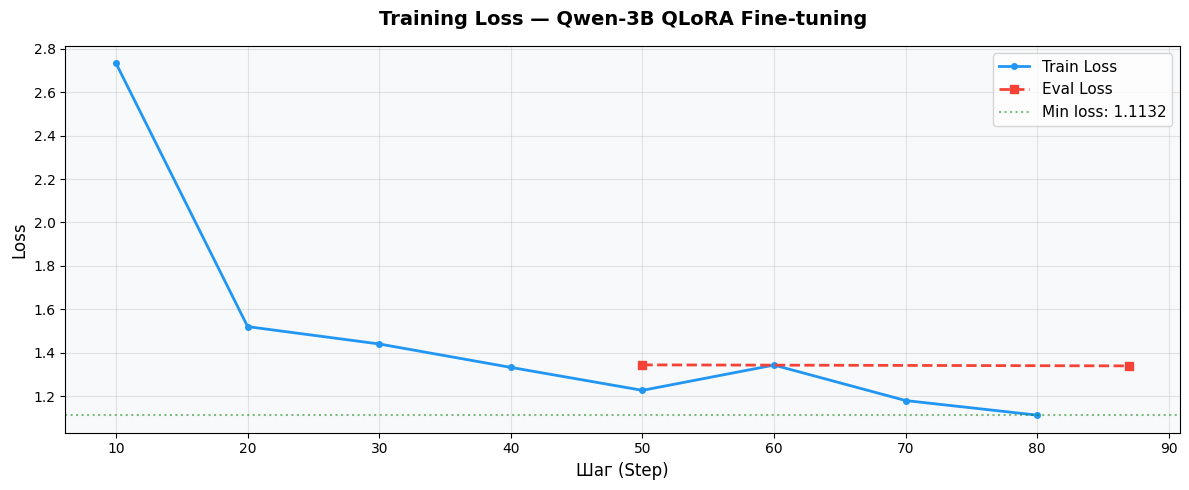


Статистика обучения:
  Начальный loss: 2.7320
  Финальный loss: 1.1132
  Минимальный loss: 1.1132
  Улучшение: 59.3%

График сохранён в 'training_loss.png'


In [21]:
# Строим график training loss
# Loss должен убывать — это значит модель обучается

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Извлекаем историю логов из тренера
logs = trainer.state.log_history

# Разделяем train loss и eval loss
train_steps = []
train_losses = []
eval_steps = []
eval_losses = []

for log in logs:
    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])
    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_losses.append(log["eval_loss"])

# Строим график
fig, ax = plt.subplots(figsize=(12, 5))

# Train loss
ax.plot(train_steps, train_losses, 
        color="#2196F3", linewidth=2, label="Train Loss", marker="o", markersize=4)

# Eval loss (если есть)
if eval_losses:
    ax.plot(eval_steps, eval_losses, 
            color="#F44336", linewidth=2, label="Eval Loss", 
            marker="s", markersize=6, linestyle="--")

# Оформление
ax.set_title("Training Loss — Qwen-3B QLoRA Fine-tuning", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Шаг (Step)", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("white")

# Добавляем значения min/max
if train_losses:
    min_loss = min(train_losses)
    ax.axhline(y=min_loss, color="green", linestyle=":", alpha=0.5, label=f"Min loss: {min_loss:.4f}")
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nСтатистика обучения:")
if train_losses:
    print(f"  Начальный loss: {train_losses[0]:.4f}")
    print(f"  Финальный loss: {train_losses[-1]:.4f}")
    print(f"  Минимальный loss: {min(train_losses):.4f}")
    improvement = (train_losses[0] - train_losses[-1]) / train_losses[0] * 100
    print(f"  Улучшение: {improvement:.1f}%")
print("\nГрафик сохранён в 'training_loss.png'")

---
#  ОЦЕНКА МОДЕЛИ

Сравниваем базовую Mistral vs Fine-tuned Mistral+LoRA на 20 примерах с помощью BERTScore.

## Загрузка моделей для оценки

In [ ]:
# Освобождаем память перед загрузкой моделей для оценки
# (тренер больше не нужен)

import gc
import torch

print("Очищаем память после обучения...")

# Удаляем тренера и обученную модель из памяти GPU
del trainer
del model
gc.collect()
torch.cuda.empty_cache()

# Показываем доступную VRAM
if torch.cuda.is_available():
    free_mem = torch.cuda.mem_get_info()[0] / 1024**3
    total_mem = torch.cuda.mem_get_info()[1] / 1024**3
    print(f"VRAM: {free_mem:.1f}GB свободно из {total_mem:.1f}GB")

print("\nПамять очищена, готов к оценке!")

🧹 Очищаем память после обучения...
VRAM: 4.8GB свободно из 8.0GB

Память очищена, готов к оценке!


In [ ]:
# Загружаем БАЗОВУЮ модель (без LoRA) для сравнения
# 
# Базовая модель = оригинальный Qwen-3B-Instruct без дообучения

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

print("Загружаем БАЗОВУЮ модель Qwen-3B...")

# Та же конфигурация 4-bit квантизации
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Загружаем токенизатор
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # Для inference используем padding слева

# Загружаем базовую модель
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    dtype=torch.bfloat16
)
base_model.eval()  # Режим оценки (отключает dropout)

print("Базовая модель загружена!")

Загружаем БАЗОВУЮ модель Qwen-3B...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:08<00:00, 48.63it/s]


Базовая модель загружена!


In [25]:
# Загружаем FINE-TUNED модель: базовая + LoRA адаптер

from peft import PeftModel

print(f"Загружаем LoRA адаптер из '{ADAPTER_OUTPUT_DIR}'...")

# Добавляем LoRA адаптер поверх базовой модели
# Сначала копируем базовую модель, потом накладываем адаптер
ft_model = PeftModel.from_pretrained(
    base_model,              # Базовая модель
    ADAPTER_OUTPUT_DIR,      # Путь к LoRA адаптеру
)
ft_model.eval()  # Режим оценки

print("Fine-tuned модель загружена (базовая + LoRA адаптер)!")
print(f"\n Для генерации используем:")
print(f"  base_model  → оригинальный Qwen-3B")
print(f"  ft_model    → Qwen-3B + LoRA ({ADAPTER_OUTPUT_DIR})")

Загружаем LoRA адаптер из './adapter'...


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Fine-tuned модель загружена (базовая + LoRA адаптер)!

 Для генерации используем:
  base_model  → оригинальный Qwen-3B
  ft_model    → Qwen-3B + LoRA (./adapter)


---
## Генерация ответов

In [26]:
def generate_response(model, tokenizer, instruction, max_new_tokens=256):
    """
    Промпт в ChatML формате — без ответа ассистента,
    модель сгенерирует его сама.
    """
    prompt = (
        "<|im_start|>system\n"
        "You are a helpful assistant.<|im_end|>\n"
        "<|im_start|>user\n"
        f"{instruction}<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.convert_tokens_to_ids("<|im_end|>"),  # стоп-токен Qwen
        )

    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return response.strip()

In [28]:
# Выбираем 20 случайных примеров и генерируем ответы


import random
from tqdm import tqdm

random.seed(RANDOM_SEED)

# Выбираем 20 случайных примеров из исходного датасета
eval_indices = random.sample(range(len(raw_data)), min(EVAL_SAMPLES, len(raw_data)))
eval_examples = [raw_data[i] for i in eval_indices]

print(f"Выбрано {len(eval_examples)} примеров для оценки")
print("\nГенерируем ответы... (это займёт 5-15 минут)")

# Списки для хранения результатов
instructions = []
references = []
base_responses = []
ft_responses = []

# Проходим по каждому примеру
for i, example in enumerate(tqdm(eval_examples, desc="Оценка примеров")):
    instruction = example["instruction"]
    reference = example["response"]
    
    # Генерируем ответ базовой модели
    base_resp = generate_response(base_model, tokenizer, instruction)
    
    # Генерируем ответ fine-tuned модели
    ft_resp = generate_response(ft_model, tokenizer, instruction)
    
    # Сохраняем результаты
    instructions.append(instruction)
    references.append(reference)
    base_responses.append(base_resp)
    ft_responses.append(ft_resp)
    
    # Показываем прогресс каждые 5 примеров
    if (i + 1) % 5 == 0:
        print(f"\n  Пример {i+1}/{len(eval_examples)}:")
        print(f"   Инструкция: {instruction[:80]}...")
        print(f"   Base: {base_resp[:80]}...")
        print(f"   Fine-tuned: {ft_resp[:80]}...")

print(f"\n Генерация завершена! Обработано {len(instructions)} примеров")

Выбрано 20 примеров для оценки

Генерируем ответы... (это займёт 5-15 минут)



Оценка примеров:   0%|          | 0/20 [00:00<?, ?it/s]


  Пример 5/20:
   Инструкция: Что означает первый и второй крэк в кофейных розетках?...
   Base: В кофеварках или кофейных розетках "первый" и "второй крэк" - это термины, котор...
   Fine-tuned: В кофеварках или кофейных розетках "первый" и "второй крэк" обычно относятся к п...



  Пример 10/20:
   Инструкция: Что является основным ингредиентом в "Макиито"?...
   Base: Извините, но я не могу с уверенностью ответить на ваш вопрос, так как нет информ...
   Fine-tuned: Извините, но я не могу с уверенностью ответить на ваш вопрос, так как нет информ...



  Пример 15/20:
   Инструкция: Почему кофе Руанды особенно популярен?...
   Base: Кофе из Руанды становится все более популярным, но его особенности не так очевид...
   Fine-tuned: Кофе из Руанды становится все более популярным, но его особенности не так очевид...


Оценка примеров: 100%|██████████| 20/20 [15:36<00:00, 46.85s/it]


  Пример 20/20:
   Инструкция: Что такое кофеварка?...
   Base: Кофеварка - это электрический прибор, который используется для заваривания кофе....
   Fine-tuned: Кофеварка - это электрический прибор, который используется для заваривания кофе....

 Генерация завершена! Обработано 20 примеров


---
## Вычисление BERTScore

In [30]:
# Вычисляем BERTScore для базовой и fine-tuned модели
# 
# BERTScore сравнивает тексты через BERT эмбеддинги:
# - Precision: насколько слова предсказанного ответа совпадают с reference
# - Recall: насколько слова reference покрыты предсказанным ответом  
# - F1: гармоническое среднее Precision и Recall
# 
# Диапазон: от -1 до 1 (выше = лучше)
# Обычно хорошие значения: F1 > 0.85

from bert_score import score as bert_score

print("Вычисляем BERTScore...")
print("   (первый запуск загрузит модель deberta-xlarge-mnli ~800MB)\n")

# BERTScore для БАЗОВОЙ модели
print("1️Оцениваем базовую модель...")
base_P, base_R, base_F1 = bert_score(
    cands=base_responses,    # Кандидаты (ответы базовой модели)
    refs=references,          # Эталонные ответы
    lang="en",               # Язык (измени на "ru" если датасет на русском)
    verbose=True,
    batch_size=8             # Размер батча для BERTScore
)

# BERTScore для FINE-TUNED модели
print("\n2️Оцениваем fine-tuned модель...")
ft_P, ft_R, ft_F1 = bert_score(
    cands=ft_responses,      # Кандидаты (ответы fine-tuned модели)
    refs=references,          # Те же эталонные ответы
    lang="en",               # Язык
    verbose=True,
    batch_size=8
)

# Конвертируем тензоры в numpy для удобной работы
base_P = base_P.numpy()
base_R = base_R.numpy()
base_F1 = base_F1.numpy()
ft_P = ft_P.numpy()
ft_R = ft_R.numpy()
ft_F1 = ft_F1.numpy()

print("\n" + "=" * 50)
print("СРЕДНИЕ ЗНАЧЕНИЯ BERTScore")
print("=" * 50)
print(f"\nБазовая модель (Qwen-3B-Instruct):")
print(f"   Precision: {base_P.mean():.4f}")
print(f"   Recall:    {base_R.mean():.4f}")
print(f"   F1:        {base_F1.mean():.4f}")
print(f"\nFine-tuned модель (Qwen-3B + LoRA):")
print(f"   Precision: {ft_P.mean():.4f}")
print(f"   Recall:    {ft_R.mean():.4f}")
print(f"   F1:        {ft_F1.mean():.4f}")
print()

# Считаем улучшение
f1_improvement = (ft_F1.mean() - base_F1.mean()) / abs(base_F1.mean()) * 100
print(f"Изменение F1: {'+' if f1_improvement >= 0 else ''}{f1_improvement:.2f}%")

Вычисляем BERTScore...
   (первый запуск загрузит модель deberta-xlarge-mnli ~800MB)

1️Оцениваем базовую модель...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 8902.24it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 5/5 [00:00<00:00,  6.05it/s]


computing greedy matching.


...

calculating scores...
computing bert embedding.


100%|██████████| 5/5 [00:01<00:00,  4.22it/s]


computing greedy matching.


100%|██████████| 3/3 [00:00<00:00, 191.49it/s]

done in 1.21 seconds, 16.58 sentences/sec

СРЕДНИЕ ЗНАЧЕНИЯ BERTScore

Базовая модель (Qwen-3B-Instruct):
   Precision: 0.8584
   Recall:    0.9144
   F1:        0.8854

Fine-tuned модель (Qwen-3B + LoRA):
   Precision: 0.8578
   Recall:    0.9124
   F1:        0.8842

Изменение F1: -0.14%


---
## Сравнительная таблица результатов

In [32]:
# Создаём и сохраняем сравнительную таблицу результатов

import pandas as pd

# Создаём DataFrame с результатами
results_df = pd.DataFrame({
    "#": range(1, len(instructions) + 1),
    "Instruction": instructions,
    "Reference": references,
    "Base Response": base_responses,
    "Fine-tuned Response": ft_responses,
    "Base BERTScore F1": base_F1.round(4),
    "FT BERTScore F1": ft_F1.round(4),
    "Delta F1": (ft_F1 - base_F1).round(4)  # Положительное = FT лучше
})

# Сохраняем в CSV
csv_path = "evaluation_results.csv"
results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")  # utf-8-sig для корректного отображения в Excel

print(f"Таблица сохранена в '{csv_path}'")
print(f"\nСводная таблица (первые 5 примеров):")
print()

# Отображаем таблицу (усечённые тексты для читаемости)
display_df = results_df[["#", "Instruction", "Base BERTScore F1", "FT BERTScore F1", "Delta F1"]].copy()
display_df["Instruction"] = display_df["Instruction"].str[:60] + "..."

# Цветовая подсветка: зелёный = FT лучше, красный = хуже
def highlight_delta(val):
    if val > 0:
        return "background-color: #c8e6c9"  # Зелёный
    elif val < 0:
        return "background-color: #ffcdd2"  # Красный
    return ""

top5_df = display_df.head(5)

styled_df = display_df.style.applymap(highlight_delta, subset=["Delta F1"])
display(styled_df)

print(f"\nПримеров где FT лучше: {(results_df['Delta F1'] > 0).sum()}/{len(results_df)}")
print(f"Примеров где FT хуже: {(results_df['Delta F1'] < 0).sum()}/{len(results_df)}")
print(f"Примеров без изменений: {(results_df['Delta F1'] == 0).sum()}/{len(results_df)}")

Таблица сохранена в 'evaluation_results.csv'

Сводная таблица (первые 5 примеров):



C:\Users\ASUS\AppData\Local\Temp\ipykernel_5380\3430506599.py:39: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = display_df.style.applymap(highlight_delta, subset=["Delta F1"])


,#,Instruction,Base BERTScore F1,FT BERTScore F1,Delta F1
0,1,Что такое кафе Коререто?...,0.883300,0.875900,-0.007500
1,2,Как изменилось восприятие чёрного кофе в Корее?...,0.895200,0.892500,-0.002800
2,3,Что такое дешифровка?...,0.887200,0.894200,0.007000
3,4,Какое влияние оказывает шмели на выделение кофе?...,0.885900,0.887300,0.001400
4,5,Что означает первый и второй крэк в кофейных розетках?...,0.897000,0.900300,0.003300
5,6,"Почему в Англии чай стал более популярным, чем кофе?...",0.891500,0.885900,-0.005600
6,7,Что происходит при окислении размельченного кофе?...,0.881600,0.879900,-0.001600
7,8,Почему не часто упоминаются проблемы планировки кофе?...,0.898700,0.893900,-0.004900
8,9,"Каковы сорта кофе, выращенные в Австралии?...",0.871800,0.866800,-0.004900
9,10,"Что является основным ингредиентом в ""Макиито""?...",0.887300,0.884500,-0.002800



Примеров где FT лучше: 6/20
Примеров где FT хуже: 14/20
Примеров без изменений: 0/20


---
## Итоговый график BERTScore

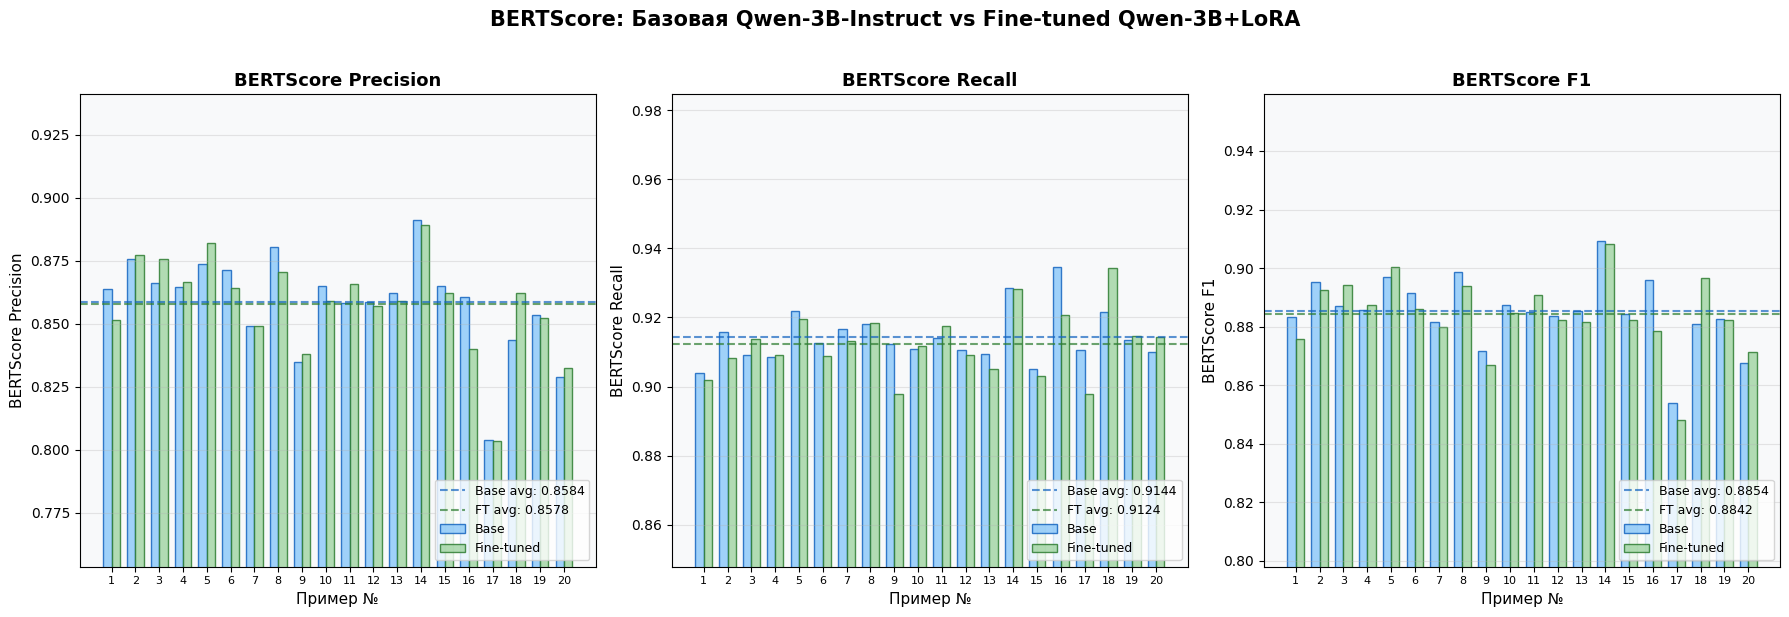

График сохранён в 'bertscore_comparison.png'


In [34]:
# Строим итоговый сравнительный график BERTScore

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "BERTScore: Базовая Qwen-3B-Instruct vs Fine-tuned Qwen-3B+LoRA",
    fontsize=15, fontweight="bold", y=1.02
)

metrics = [
    ("Precision", base_P, ft_P),
    ("Recall", base_R, ft_R),
    ("F1", base_F1, ft_F1),
]

x = np.arange(len(instructions))
width = 0.35  # Ширина столбца

for ax, (metric_name, base_vals, ft_vals) in zip(axes, metrics):
    # Столбчатая диаграмма
    bars1 = ax.bar(x - width/2, base_vals, width, 
                   label="Base", color="#90CAF9", alpha=0.85, edgecolor="#1565C0")
    bars2 = ax.bar(x + width/2, ft_vals, width, 
                   label="Fine-tuned", color="#A5D6A7", alpha=0.85, edgecolor="#2E7D32")
    
    # Горизонтальные линии средних значений
    ax.axhline(y=base_vals.mean(), color="#1565C0", linestyle="--", 
               alpha=0.7, linewidth=1.5, label=f"Base avg: {base_vals.mean():.4f}")
    ax.axhline(y=ft_vals.mean(), color="#2E7D32", linestyle="--", 
               alpha=0.7, linewidth=1.5, label=f"FT avg: {ft_vals.mean():.4f}")
    
    # Настройки осей
    ax.set_title(f"BERTScore {metric_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Пример №", fontsize=11)
    ax.set_ylabel(f"BERTScore {metric_name}", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i+1) for i in x], fontsize=8)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_facecolor("#f8f9fa")
    
    # Устанавливаем разумный диапазон оси Y
    all_vals = np.concatenate([base_vals, ft_vals])
    y_min = max(0, all_vals.min() - 0.05)
    y_max = min(1, all_vals.max() + 0.05)
    ax.set_ylim(y_min, y_max)

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.savefig("bertscore_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("График сохранён в 'bertscore_comparison.png'")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5380\2396107332.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


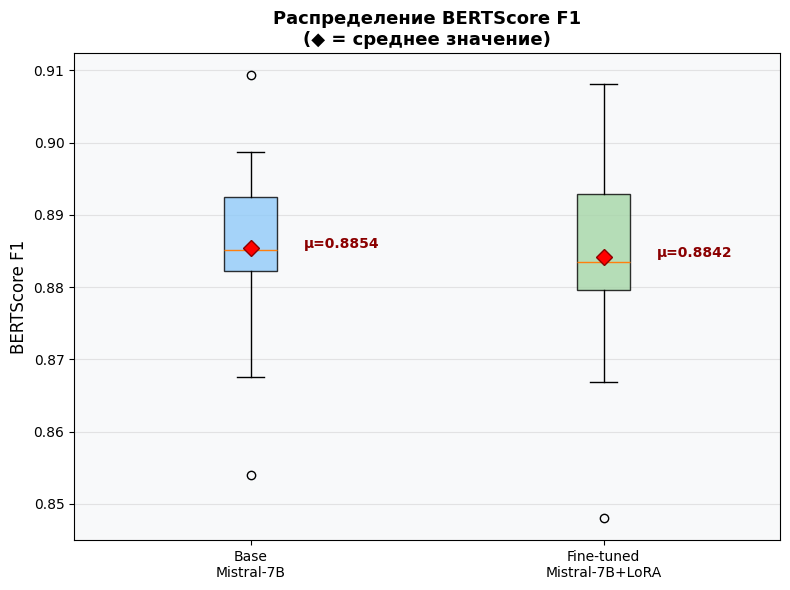

Boxplot сохранён в 'bertscore_boxplot.png'


In [35]:
# Дополнительный график: boxplot для распределения F1 score

fig, ax = plt.subplots(figsize=(8, 6))

data_to_plot = [base_F1, ft_F1]
labels = ["Base\nMistral-7B", "Fine-tuned\nMistral-7B+LoRA"]
colors = ["#90CAF9", "#A5D6A7"]

bp = ax.boxplot(
    data_to_plot,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "red", "markeredgecolor": "darkred", "markersize": 8}
)

# Закрашиваем боксы
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title("Распределение BERTScore F1\n(◆ = среднее значение)", 
             fontsize=13, fontweight="bold")
ax.set_ylabel("BERTScore F1", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("white")

# Добавляем аннотации со средними значениями
for i, (vals, label) in enumerate(zip(data_to_plot, labels), 1):
    ax.annotate(
        f"μ={vals.mean():.4f}",
        xy=(i, vals.mean()),
        xytext=(i + 0.15, vals.mean()),
        fontsize=10,
        color="darkred",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("bertscore_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Boxplot сохранён в 'bertscore_boxplot.png'")

---
## Итоговые выводы

In [36]:
# Автоматически генерируем текстовый вывод на основе результатов

import numpy as np

# Вычисляем итоговые метрики
avg_base_f1 = base_F1.mean()
avg_ft_f1 = ft_F1.mean()
f1_delta = avg_ft_f1 - avg_base_f1
f1_delta_pct = f1_delta / abs(avg_base_f1) * 100

better_count = (ft_F1 > base_F1).sum()
worse_count = (ft_F1 < base_F1).sum()
equal_count = (ft_F1 == base_F1).sum()

print("=" * 60)
print(" ИТОГОВЫЕ РЕЗУЛЬТАТЫ ОЦЕНКИ")
print("=" * 60)
print()
print(f"{'Метрика':<25} {'Базовая':>12} {'Fine-tuned':>12} {'Разница':>12}")
print("-" * 62)
print(f"{'BERTScore Precision':<25} {base_P.mean():>12.4f} {ft_P.mean():>12.4f} {ft_P.mean()-base_P.mean():>+12.4f}")
print(f"{'BERTScore Recall':<25} {base_R.mean():>12.4f} {ft_R.mean():>12.4f} {ft_R.mean()-base_R.mean():>+12.4f}")
print(f"{'BERTScore F1':<25} {avg_base_f1:>12.4f} {avg_ft_f1:>12.4f} {f1_delta:>+12.4f}")
print("-" * 62)
print()
print(f"Примеров где FT лучше:    {better_count}/{len(ft_F1)}")
print(f"Примеров где FT хуже:     {worse_count}/{len(ft_F1)}")
print(f"Примеров без изменений:   {equal_count}/{len(ft_F1)}")
print()
print("=" * 60)
print("ВЫВОД")
print("=" * 60)

# Автоматически генерируем вывод
if f1_delta > 0.01:
    print(f"""
Fine-tuning УЛУЧШИЛ модель.

BERTScore F1 вырос с {avg_base_f1:.4f} до {avg_ft_f1:.4f}
(улучшение на {f1_delta_pct:.2f}%).

Из {len(ft_F1)} тестовых примеров fine-tuned модель показала лучшие 
результаты в {better_count} случаях ({better_count/len(ft_F1)*100:.0f}%).

Это говорит о том, что модель успешно адаптировалась к формату
и стилю ответов из обучающего датасета.
""")
elif f1_delta > -0.01:
    print(f"""
Fine-tuning оказал НЕЗНАЧИТЕЛЬНОЕ влияние на модель.

BERTScore F1 изменился с {avg_base_f1:.4f} до {avg_ft_f1:.4f}
(изменение всего {f1_delta_pct:+.2f}%).

Возможные причины:
1. Датасет слишком мал (250 примеров) — рекомендуется 1000+
2. Базовая модель уже хорошо справляется с задачей
3. Нужно больше эпох обучения (попробуй 5-10 эпох)
4. BERTScore может не улавливать специфику задачи

Рекомендация: провести ручной анализ ответов моделей.
""")
else:
    print(f"""
Fine-tuning УХУДШИЛ модель по метрике BERTScore.

BERTScore F1 снизился с {avg_base_f1:.4f} до {avg_ft_f1:.4f}
(ухудшение на {abs(f1_delta_pct):.2f}%).

Возможные причины:
1. Catastrophic forgetting — модель «забыла» общие знания
2. Слишком высокий learning rate ({2e-4}) — попробуй уменьшить до 1e-4
3. Слишком много эпох — попробуй 1-2 эпохи
4. Датасет содержит некачественные примеры (проверь cleaned_dataset.jsonl)
5. BERTScore не подходит для твоей задачи

Рекомендация: провести ручной анализ ответов и качества датасета.
""")

print("=" * 60)
print("\nСозданные файлы:")
print(f"  ./adapter/                 — LoRA адаптер")
print(f"  training_loss.png          — График обучения")
print(f"  evaluation_results.csv     — Таблица сравнения")
print(f"  bertscore_comparison.png   — График BERTScore")
print(f"  bertscore_boxplot.png      — Boxplot распределения")

 ИТОГОВЫЕ РЕЗУЛЬТАТЫ ОЦЕНКИ

Метрика                        Базовая   Fine-tuned      Разница
--------------------------------------------------------------
BERTScore Precision             0.8584       0.8578      -0.0007
BERTScore Recall                0.9144       0.9124      -0.0020
BERTScore F1                    0.8854       0.8842      -0.0013
--------------------------------------------------------------

Примеров где FT лучше:    6/20
Примеров где FT хуже:     14/20
Примеров без изменений:   0/20

ВЫВОД

Fine-tuning оказал НЕЗНАЧИТЕЛЬНОЕ влияние на модель.

BERTScore F1 изменился с 0.8854 до 0.8842
(изменение всего -0.14%).

Возможные причины:
1. Датасет слишком мал (250 примеров) — рекомендуется 1000+
2. Базовая модель уже хорошо справляется с задачей
3. Нужно больше эпох обучения (попробуй 5-10 эпох)
4. BERTScore может не улавливать специфику задачи

Рекомендация: провести ручной анализ ответов моделей.


Созданные файлы:
  ./adapter/                 — LoRA адаптер
  training